# Softmax with Temperature — Exercises

Edit the values in the **Editable values** cell, then run all cells (Kernel → Restart & Run All) to see the results and charts.

Covers:
- 6.1 — softmax probabilities at T = 1
- 6.2 — effect of temperature on the top token
- 6.3 — top-p (nucleus) filtering
- 6.4 — sampling from the distribution

In [84]:
import torch
import matplotlib.pyplot as plt

## Editable values

In [85]:
LOGITS = [3.0, 2.2, 1.8, 1.5, 1.0, 0.6, 0.3, 0.1]
LABELS = ["cat", "dog", "bird", "fish", "wolf", "kingfisher", "beaver", "platypus"]  # must match LOGITS length

TEMPERATURE = 1.0  # baseline temperature used for 6.1 / 6.3

# Compared separately against the baseline for 6.2 (and used for the comparison chart)
TEMPERATURES_TO_COMPARE = [0.5, 1.0, 2.0]

# Nucleus (top-p) filtering: keep the smallest set of most-likely tokens whose
# cumulative probability reaches TOP_P. Set to 1.0 to keep everything.
TOP_P = 0.9

# Sampling comparison (6.4): draw NUM_SAMPLES tokens at each of these temperatures.
# SAMPLE_SEED makes the draw reproducible.
SAMPLE_TEMPERATURES = [0.5, 1.5]
NUM_SAMPLES = 100
SAMPLE_SEED = 0

assert len(LOGITS) == len(LABELS), "LOGITS and LABELS must be the same length"

## Core functions

In [86]:
def softmax_with_temperature(logits, temperature):
    logits = torch.as_tensor(logits, dtype=torch.float32)  # accepts a plain list or an existing tensor
    return torch.softmax(logits / temperature, dim=-1)


def top_p_mask(probs, p):
    """Boolean mask (same order as probs) marking tokens kept by top-p filtering."""
    sorted_probs, sorted_indices = torch.sort(probs, descending=True)
    cumulative = torch.cumsum(sorted_probs, dim=-1)
    cutoff = int((cumulative >= p).nonzero()[0].item())
    kept_indices = sorted_indices[: cutoff + 1]
    mask = torch.zeros_like(probs, dtype=torch.bool)
    mask[kept_indices] = True
    return mask


def sample_tokens(logits, temperature, num_samples, seed):
    """Draw `num_samples` token indices from softmax(logits / temperature), reproducibly."""
    probs = softmax_with_temperature(logits, temperature)
    generator = torch.Generator().manual_seed(seed)
    return torch.multinomial(probs, num_samples, replacement=True, generator=generator)

## 6.1 — Softmax probabilities at T = 1

In [87]:
probs = softmax_with_temperature(LOGITS, TEMPERATURE)

print(f"Softmax values (T = {TEMPERATURE}): {[round(p, 4) for p in probs.tolist()]}")
print(f"Sum of probabilities: {probs.sum().item():.6f}\n")

print(f"{'label':<12} {'logit':>8} {'probability':>12}")
for label, logit, prob in zip(LABELS, LOGITS, probs.tolist()):
    print(f"{label:<12} {logit:>8.3f} {prob:>12.3%}")

Softmax values (T = 1.0): [0.4307, 0.1935, 0.1297, 0.0961, 0.0583, 0.0391, 0.0289, 0.0237]
Sum of probabilities: 1.000000

label           logit  probability
cat             3.000      43.068%
dog             2.200      19.351%
bird            1.800      12.972%
fish            1.500       9.610%
wolf            1.000       5.829%
kingfisher      0.600       3.907%
beaver          0.300       2.894%
platypus        0.100       2.370%


## 6.2 — Effect of temperature on the top token

`softmax_with_temperature` is called **separately** for each temperature (the baseline result is never overwritten), so you can compare them side by side.

In [88]:
top_index = LOGITS.index(max(LOGITS))
top_label = LABELS[top_index]

baseline_probs = softmax_with_temperature(LOGITS, TEMPERATURE)  # separate call, kept for comparison
baseline_top_prob = baseline_probs[top_index].item()

print(f"Temperature diffs for top token '{top_label}' (baseline T = {TEMPERATURE}: {baseline_top_prob:.3%}):")
for temperature in TEMPERATURES_TO_COMPARE:
    temp_probs = softmax_with_temperature(LOGITS, temperature)  # separate call per temperature
    top_prob = temp_probs[top_index].item()
    diff = top_prob - baseline_top_prob
    sign = "+" if diff >= 0 else ""
    print(f"  T = {temperature}: {top_label} = {top_prob:.3%}  (diff vs T = {TEMPERATURE}: {sign}{diff:.3%})")

Temperature diffs for top token 'cat' (baseline T = 1.0: 43.068%):
  T = 0.5: cat = 72.648%  (diff vs T = 1.0: +29.581%)
  T = 1.0: cat = 43.068%  (diff vs T = 1.0: +0.000%)
  T = 2.0: cat = 25.944%  (diff vs T = 1.0: -17.123%)


**Why lowering the temperature raises the top token's probability:** dividing logits by a smaller T spreads them further apart before the exponential, so the softmax puts even more relative weight on the already-largest logit — sharpening the distribution around the top token.

## 6.3 — Top-p (nucleus) filtering

In [89]:
kept_flags = top_p_mask(probs, TOP_P)
kept_labels = [label for label, kept in zip(LABELS, kept_flags.tolist()) if kept]

print(f"{'label':<12} {'probability':>12} {'kept':>6}")
for label, prob, kept in zip(LABELS, probs.tolist(), kept_flags.tolist()):
    print(f"{label:<12} {prob:>12.3%} {'yes' if kept else 'no':>6}")

print(f"\nKept {len(kept_labels)} out of {len(LABELS)} tokens (top-p = {TOP_P}): {kept_labels}")

label         probability   kept
cat               43.068%    yes
dog               19.351%    yes
bird              12.972%    yes
fish               9.610%    yes
wolf               5.829%    yes
kingfisher         3.907%     no
beaver             2.894%     no
platypus           2.370%     no

Kept 5 out of 8 tokens (top-p = 0.9): ['cat', 'dog', 'bird', 'fish', 'wolf']


## Charts

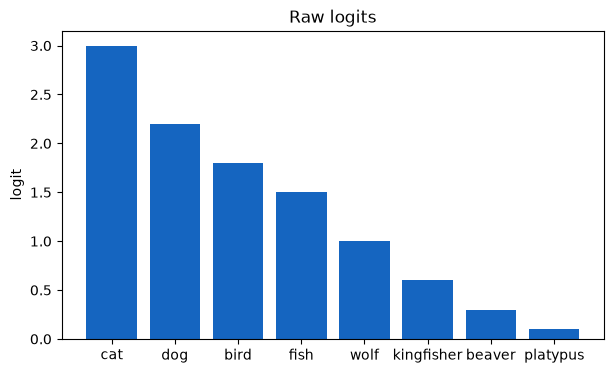

In [90]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(LABELS, LOGITS, color="#1565c0")
ax.set_title("Raw logits")
ax.set_ylabel("logit")
plt.show()

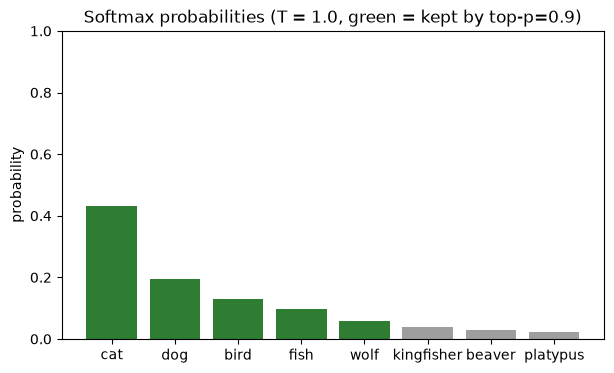

In [91]:
colors = ["#2e7d32" if kept else "#9e9e9e" for kept in kept_flags.tolist()]
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(LABELS, probs.tolist(), color=colors)
ax.set_title(f"Softmax probabilities (T = {TEMPERATURE}, green = kept by top-p={TOP_P})")
ax.set_ylabel("probability")
ax.set_ylim(0, 1)
plt.show()

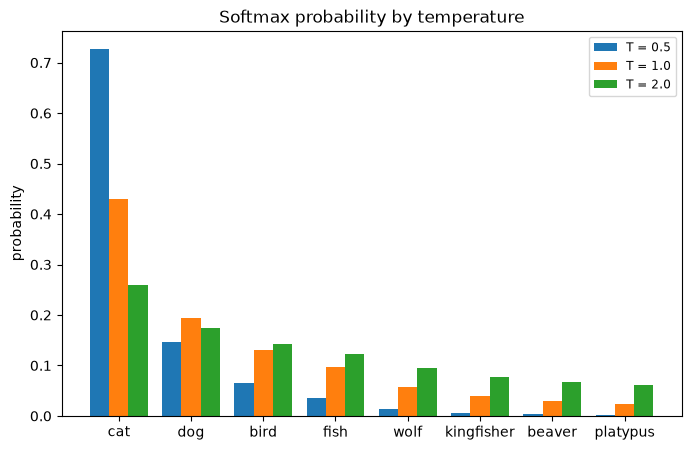

In [92]:
num_labels = len(LABELS)
num_temps = len(TEMPERATURES_TO_COMPARE)
x = list(range(num_labels))
width = 0.8 / num_temps

fig, ax = plt.subplots(figsize=(8, 5))
for i, temperature in enumerate(TEMPERATURES_TO_COMPARE):
    temp_probs = softmax_with_temperature(LOGITS, temperature).tolist()
    offset = (i - (num_temps - 1) / 2) * width
    bar_positions = [xi + offset for xi in x]
    ax.bar(bar_positions, temp_probs, width, label=f"T = {temperature}")

ax.set_xticks(x)
ax.set_xticklabels(LABELS)
ax.set_ylabel("probability")
ax.set_title("Softmax probability by temperature")
ax.legend(loc="upper right", fontsize="small")
plt.show()

## 6.4 — Sampling from the distribution

Draw `NUM_SAMPLES` tokens at each temperature in `SAMPLE_TEMPERATURES` (seeded for reproducibility), and count how often **every** label comes up — not just the top one — so you can see the full spread of outcomes.

In [93]:
print(f"Sampling {NUM_SAMPLES} tokens per temperature (seed={SAMPLE_SEED}):")
for temperature in SAMPLE_TEMPERATURES:
    samples = sample_tokens(LOGITS, temperature, NUM_SAMPLES, SAMPLE_SEED)  # separate call per temperature
    print(f"\n  T = {temperature}:")
    for index, label in enumerate(LABELS):
        count = int((samples == index).sum().item())
        print(f"    {label:<12} {count:>3}/{NUM_SAMPLES} ({count / NUM_SAMPLES:.1%})")

Sampling 100 tokens per temperature (seed=0):

  T = 0.5:
    cat           77/100 (77.0%)
    dog           15/100 (15.0%)
    bird           4/100 (4.0%)
    fish           1/100 (1.0%)
    wolf           1/100 (1.0%)
    kingfisher     0/100 (0.0%)
    beaver         1/100 (1.0%)
    platypus       1/100 (1.0%)

  T = 1.5:
    cat           32/100 (32.0%)
    dog           21/100 (21.0%)
    bird          16/100 (16.0%)
    fish          11/100 (11.0%)
    wolf           9/100 (9.0%)
    kingfisher     4/100 (4.0%)
    beaver         3/100 (3.0%)
    platypus       4/100 (4.0%)


**Explanation:** at low temperature the distribution is sharp, so most samples land on the top token; at high temperature the distribution is flatter, so probability mass — and therefore sample counts — spread out across more tokens.

## Bonus — real logits from a model, with top-k and top-p combined

Instead of hand-typed logits, this section:
1. Downloads a small public dataset (`fancyzhx/ag_news`) and picks one real sentence from it as a prompt.
2. Loads a small free local model (`distilgpt2`, no API key needed) and runs it on that prompt to get **real** next-token logits.
3. Reuses `softmax_with_temperature` from above, then applies top-k **and** top-p together (`MODEL_K` and `MODEL_P` below) to the real distribution — the common real-world combo: top-k narrows the candidates first, then top-p further trims within that set.

In [94]:
import random

from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer

### Editable values (bonus section)

In [95]:
MODEL_NAME = "distilgpt2"

DATASET_NAME = "fancyzhx/ag_news"
DATASET_SPLIT = "test"
PROMPT_INDEX = 15  # set to an integer to pick a specific example; None = a different random one each run
PROMPT_WORDS = 12  # how many words of that example to feed the model

MODEL_TEMPERATURE = 1.0

# Applied together: top-k first narrows to the k most likely tokens, then top-p
# further narrows within that set. Set MODEL_K to the vocab size (or MODEL_P to 1.0)
# to effectively disable one of them.
MODEL_K = 8
MODEL_P = 0.9

TOP_N_DISPLAY = 12  # how many top tokens to show in the table/chart (vocab is ~50k, too many to show all)

# Sampling comparison (answers 6.4 using the real model's distribution)
MODEL_SAMPLE_TEMPERATURES = [0.5, 1.5]
MODEL_NUM_SAMPLES = 100
MODEL_SAMPLE_SEED = 0

In [96]:
dataset = load_dataset(DATASET_NAME, split=DATASET_SPLIT)
prompt_index = PROMPT_INDEX if PROMPT_INDEX is not None else random.randrange(len(dataset))
example_text = dataset[prompt_index]["text"]
prompt = " ".join(example_text.split()[:PROMPT_WORDS])

print(f"Dataset example #{prompt_index}: {example_text!r}")
print(f"Prompt fed to the model: {prompt!r}")

Dataset example #15: "Teenage T. rex's monster growth Tyrannosaurus rex achieved its massive size due to an enormous growth spurt during its adolescent years."
Prompt fed to the model: "Teenage T. rex's monster growth Tyrannosaurus rex achieved its massive size due"


In [97]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)
model.eval()


def get_next_token_logits(tokenizer, model, prompt):
    inputs = tokenizer(prompt, return_tensors="pt")
    with torch.no_grad():
        outputs = model(**inputs)
    return outputs.logits[0, -1, :]  # raw scores for the next token, one per vocab entry


def top_k_mask(probs, k):
    """Boolean mask (same order as probs) marking the k highest-probability tokens."""
    sorted_probs, sorted_indices = torch.sort(probs, descending=True)
    kept_indices = sorted_indices[:k]
    mask = torch.zeros_like(probs, dtype=torch.bool)
    mask[kept_indices] = True
    return mask


model_logits = get_next_token_logits(tokenizer, model, prompt)

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

In [98]:
model_probs = softmax_with_temperature(model_logits, MODEL_TEMPERATURE)

k_kept = top_k_mask(model_probs, MODEL_K)
p_kept = top_p_mask(model_probs, MODEL_P)
model_kept = k_kept & p_kept  # combined: must survive both filters
strategy_desc = f"top-k (k={MODEL_K}) + top-p (p={MODEL_P})"

sorted_probs, sorted_indices = torch.sort(model_probs, descending=True)
display_count = min(TOP_N_DISPLAY, len(sorted_probs))
display_indices = sorted_indices[:display_count]
display_tokens = [tokenizer.decode([idx]).strip() or "·" for idx in display_indices]
display_probs = sorted_probs[:display_count].tolist()
display_kept = model_kept[display_indices].tolist()
kept_count = int(model_kept.sum().item())

print(f"Prompt: {prompt!r}")
print(f"Temperature: {MODEL_TEMPERATURE}  Filters: {strategy_desc}")
print(f"Kept {kept_count} out of {model_probs.shape[0]} tokens in the vocabulary\n")

print(f"{'token':<15} {'probability':>12} {'kept':>6}")
for token, prob, kept in zip(display_tokens, display_probs, display_kept):
    print(f"{token:<15} {prob:>12.3%} {'yes' if kept else 'no':>6}")

Prompt: "Teenage T. rex's monster growth Tyrannosaurus rex achieved its massive size due"
Temperature: 1.0  Filters: top-k (k=8) + top-p (p=0.9)
Kept 1 out of 50257 tokens in the vocabulary

token            probability   kept
to                   96.592%    yes
in                    2.481%     no
largely               0.114%     no
mainly                0.059%     no
the                   0.052%     no
primarily             0.051%     no
not                   0.048%     no
,                     0.047%     no
mostly                0.038%     no
both                  0.031%     no
its                   0.030%     no
partly                0.021%     no


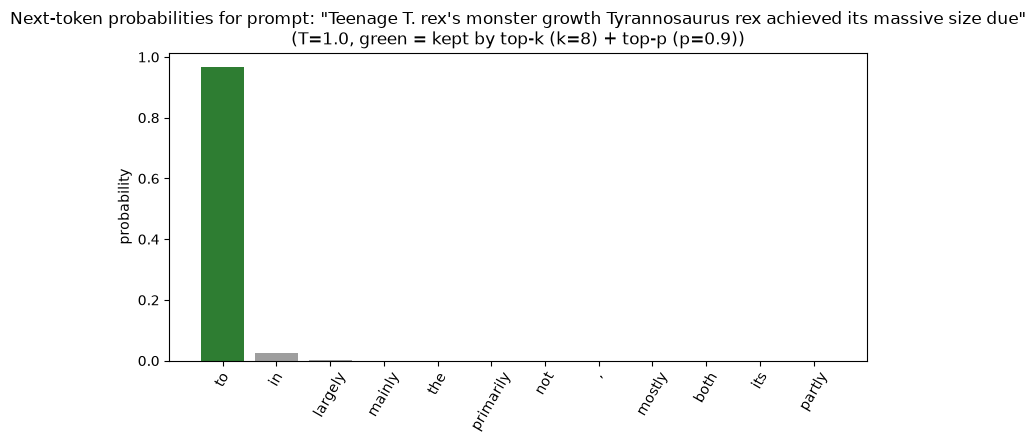

In [99]:
colors = ["#2e7d32" if kept else "#9e9e9e" for kept in display_kept]
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(display_tokens, display_probs, color=colors)
ax.set_title(f"Next-token probabilities for prompt: {prompt!r}\n(T={MODEL_TEMPERATURE}, green = kept by {strategy_desc})")
ax.set_ylabel("probability")
ax.tick_params(axis="x", rotation=60)
plt.show()

### 6.4 (bonus) — sampling from the real model's distribution

Same idea as 6.4 above, but drawing from distilgpt2's actual next-token distribution for this prompt instead of the hand-typed logits. We track the tokens shown in the table above (the top `TOP_N_DISPLAY`) plus a catch-all "other" bucket for everything outside that shortlist, since the full vocabulary has ~50k entries.

In [100]:
print(f"Sampling {MODEL_NUM_SAMPLES} tokens per temperature (seed={MODEL_SAMPLE_SEED}):")
for temperature in MODEL_SAMPLE_TEMPERATURES:
    samples = sample_tokens(model_logits, temperature, MODEL_NUM_SAMPLES, MODEL_SAMPLE_SEED)  # separate call per temperature
    print(f"\n  T = {temperature}:")
    tracked_count = 0
    for token, index in zip(display_tokens, display_indices.tolist()):
        count = int((samples == index).sum().item())
        tracked_count += count
        print(f"    {token:<15} {count:>3}/{MODEL_NUM_SAMPLES} ({count / MODEL_NUM_SAMPLES:.1%})")
    other_count = MODEL_NUM_SAMPLES - tracked_count
    print(f"    {'(other tokens)':<15} {other_count:>3}/{MODEL_NUM_SAMPLES} ({other_count / MODEL_NUM_SAMPLES:.1%})")

Sampling 100 tokens per temperature (seed=0):

  T = 0.5:
    to              100/100 (100.0%)
    in                0/100 (0.0%)
    largely           0/100 (0.0%)
    mainly            0/100 (0.0%)
    the               0/100 (0.0%)
    primarily         0/100 (0.0%)
    not               0/100 (0.0%)
    ,                 0/100 (0.0%)
    mostly            0/100 (0.0%)
    both              0/100 (0.0%)
    its               0/100 (0.0%)
    partly            0/100 (0.0%)
    (other tokens)    0/100 (0.0%)

  T = 1.5:
    to               72/100 (72.0%)
    in                6/100 (6.0%)
    largely           0/100 (0.0%)
    mainly            1/100 (1.0%)
    the               1/100 (1.0%)
    primarily         0/100 (0.0%)
    not               0/100 (0.0%)
    ,                 1/100 (1.0%)
    mostly            0/100 (0.0%)
    both              0/100 (0.0%)
    its               1/100 (1.0%)
    partly            0/100 (0.0%)
    (other tokens)   18/100 (18.0%)
